# Keras TF 2.0 - Code Along Classification Project

Let's explore a classification task with Keras API for TF 2.0

## The Data

### Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry 
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 3 is Mean Radius, field
        13 is Radius SE, field 23 is Worst Radius.

        - class:
                - WDBC-Malignant
                - WDBC-Benign

    :Summary Statistics:

    ===================================== ====== ======
                                           Min    Max
    ===================================== ====== ======
    radius (mean):                        6.981  28.11
    texture (mean):                       9.71   39.28
    perimeter (mean):                     43.79  188.5
    area (mean):                          143.5  2501.0
    smoothness (mean):                    0.053  0.163
    compactness (mean):                   0.019  0.345
    concavity (mean):                     0.0    0.427
    concave points (mean):                0.0    0.201
    symmetry (mean):                      0.106  0.304
    fractal dimension (mean):             0.05   0.097
    radius (standard error):              0.112  2.873
    texture (standard error):             0.36   4.885
    perimeter (standard error):           0.757  21.98
    area (standard error):                6.802  542.2
    smoothness (standard error):          0.002  0.031
    compactness (standard error):         0.002  0.135
    concavity (standard error):           0.0    0.396
    concave points (standard error):      0.0    0.053
    symmetry (standard error):            0.008  0.079
    fractal dimension (standard error):   0.001  0.03
    radius (worst):                       7.93   36.04
    texture (worst):                      12.02  49.54
    perimeter (worst):                    50.41  251.2
    area (worst):                         185.2  4254.0
    smoothness (worst):                   0.071  0.223
    compactness (worst):                  0.027  1.058
    concavity (worst):                    0.0    1.252
    concave points (worst):               0.0    0.291
    symmetry (worst):                     0.156  0.664
    fractal dimension (worst):            0.055  0.208
    ===================================== ====== ======

    :Missing Attribute Values: None

    :Class Distribution: 212 - Malignant, 357 - Benign

    :Creator:  Dr. William H. Wolberg, W. Nick Street, Olvi L. Mangasarian

    :Donor: Nick Street

    :Date: November, 1995

In [16]:
import pandas as pd
import numpy as np

In [17]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['benign_0__mal_1'] = cancer.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [19]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## EDA

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='benign_0__mal_1', ylabel='count'>

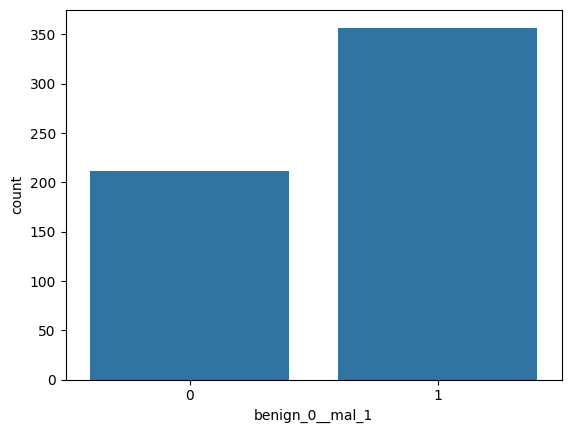

In [21]:
sns.countplot(x='benign_0__mal_1', data=df)

<Axes: >

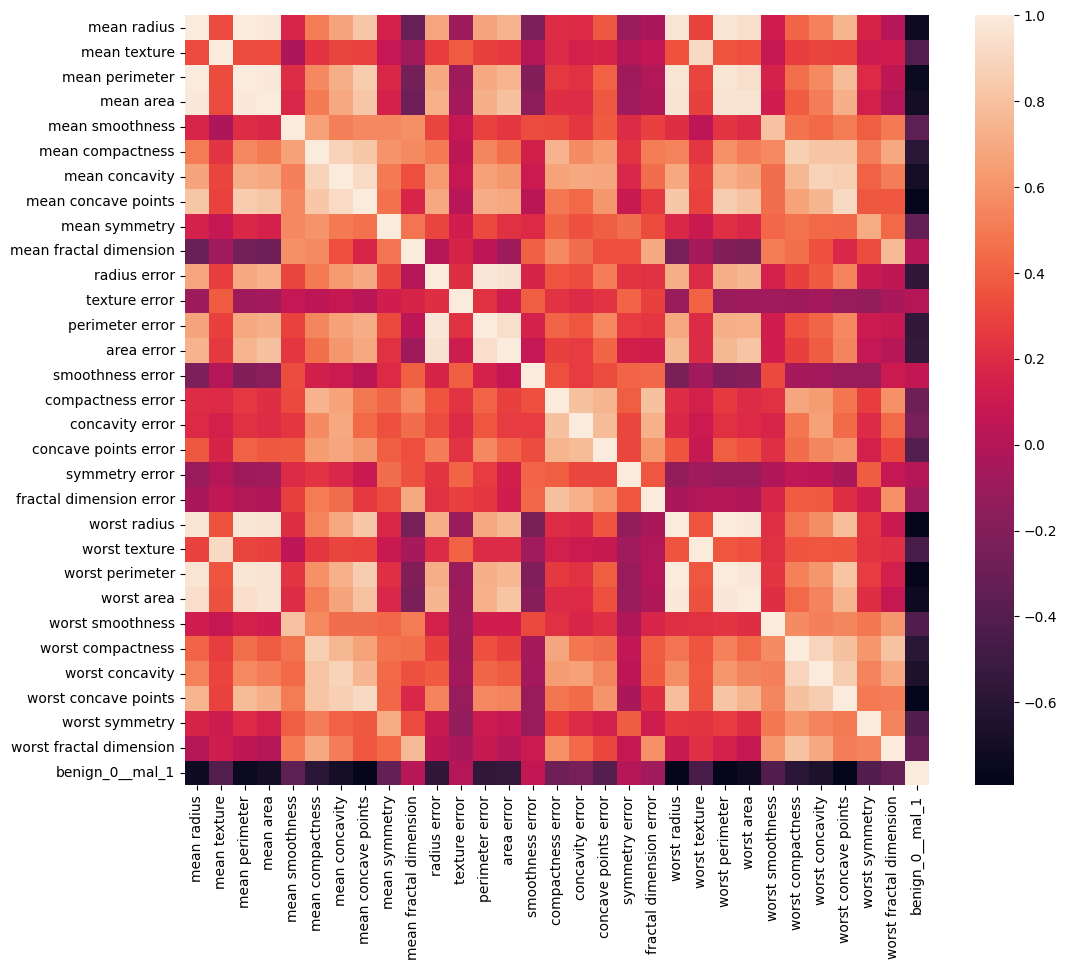

In [22]:
plt.figure(figsize=(12,10))  
sns.heatmap(df.corr())

<Axes: >

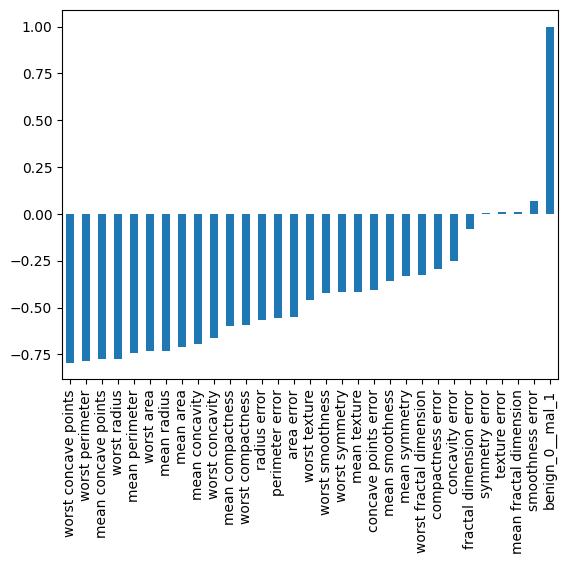

In [23]:
df.corr()['benign_0__mal_1'].sort_values().plot(kind='bar')

## Train Test Split

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X = df.drop('benign_0__mal_1', axis=1).values
y = df['benign_0__mal_1'].values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)


## Scaling Data

In [26]:
from sklearn.preprocessing import MinMaxScaler

In [27]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

## Creating the Model

    # For a binary classification problem
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
                  
    

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

In [29]:
model = Sequential()
model.add(Dense(30, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')

## Training the Model 

### Example One: Choosing too many epochs and overfitting!

In [31]:
model.fit(x=X_train, 
          y=y_train, 
          epochs=600, 
          validation_data=(X_test, y_test), 
          verbose=1)

Epoch 1/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.6978 - val_loss: 0.6694
Epoch 2/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6447 - val_loss: 0.6135
Epoch 3/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5899 - val_loss: 0.5635
Epoch 4/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5349 - val_loss: 0.5068
Epoch 5/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4778 - val_loss: 0.4510
Epoch 6/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4228 - val_loss: 0.3967
Epoch 7/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3773 - val_loss: 0.3495
Epoch 8/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3362 - val_loss: 0.3092
Epoch 9/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2992 - val_loss: 0.2765
Epoch 10/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2714 - val_loss: 0.2500
Epoch 11/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2486 - val_loss: 0.2279
Epoch 12/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.

In [32]:
losses = pd.DataFrame(model.history.history)

<Axes: >

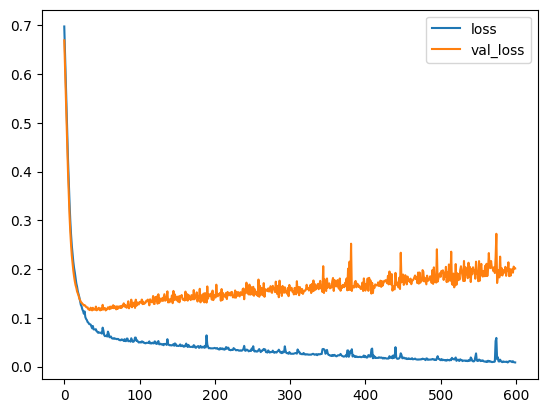

In [33]:
losses.plot()

## Example Two: Early Stopping

We obviously trained too much! Let's use early stopping to track the val_loss and stop training once it begins increasing too much!

In [34]:
from tensorflow.keras.callbacks import EarlyStopping

Stop training when a monitored quantity has stopped improving.

    Arguments:
        monitor: Quantity to be monitored.
        min_delta: Minimum change in the monitored quantity
            to qualify as an improvement, i.e. an absolute
            change of less than min_delta, will count as no
            improvement.
        patience: Number of epochs with no improvement
            after which training will be stopped.
        verbose: verbosity mode.
        mode: One of `{"auto", "min", "max"}`. In `min` mode,
            training will stop when the quantity
            monitored has stopped decreasing; in `max`
            mode it will stop when the quantity
            monitored has stopped increasing; in `auto`
            mode, the direction is automatically inferred
            from the name of the monitored quantity.

In [35]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25)

model.fit(x=X_train, 
          y=y_train, 
          epochs=600, 
          validation_data=(X_test, y_test), 
          verbose=1,
          callbacks=[early_stop]) 

Epoch 1/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0084 - val_loss: 0.2049
Epoch 2/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0092 - val_loss: 0.2075
Epoch 3/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0093 - val_loss: 0.2110
Epoch 4/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0084 - val_loss: 0.1947
Epoch 5/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0094 - val_loss: 0.2121
Epoch 6/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0079 - val_loss: 0.1985
Epoch 7/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0089 - val_loss: 0.1977
Epoch 8/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0094 - val_loss: 0.2185
Epoch 9/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0091 - val_loss: 0.2192
Epoch 10/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0085 - val_loss: 0.1987
Epoch 11/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0088 - val_loss: 0.2205
Epoch 12/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.

<Axes: >

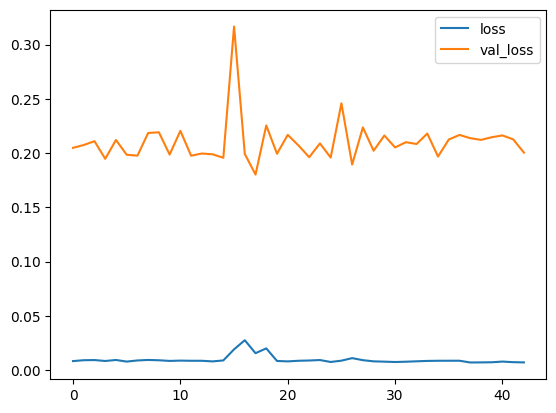

In [38]:
losses = pd.DataFrame(model.history.history)
losses.plot()

## Example Three: Adding in DropOut Layers

In [39]:
from tensorflow.keras.layers import Dropout

In [40]:
model = Sequential()
model.add(Dense(30, activation='relu'))
model.add(Dropout(0.5)) 
model.add(Dense(15, activation='relu'))
model.add(Dropout(0.5)) 
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')
model.fit(x=X_train, 
          y=y_train, 
          epochs=600, 
          validation_data=(X_test, y_test), 
          verbose=1)

Epoch 1/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6982 - val_loss: 0.6883
Epoch 2/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6979 - val_loss: 0.6796
Epoch 3/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6854 - val_loss: 0.6720
Epoch 4/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6677 - val_loss: 0.6588
Epoch 5/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6577 - val_loss: 0.6426
Epoch 6/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6404 - val_loss: 0.6190
Epoch 7/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6188 - val_loss: 0.5848
Epoch 8/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5903 - val_loss: 0.5483
Epoch 9/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5784 - val_loss: 0.5166
Epoch 10/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5534 - val_loss: 0.4818
Epoch 11/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5229 - val_loss: 0.4534
Epoch 12/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.

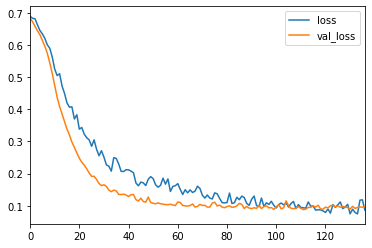

In [ ]:
losses = pd.DataFrame(model.history.history)
losses.plot()

# Model Evaluation

In [43]:
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import classification_report

In [44]:
predictions = (model.predict(X_test) > 0.5).astype("int32")
report_dict = classification_report(y_test, predictions, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step 


,precision,recall,f1-score,support
0,0.931818,0.976190,0.953488,42.000000
1,0.985714,0.958333,0.971831,72.000000
accuracy,0.964912,0.964912,0.964912,0.964912
macro avg,0.958766,0.967262,0.962660,114.000000
weighted avg,0.965858,0.964912,0.965073,114.000000


Text(45.722222222222214, 0.5, 'Actual')

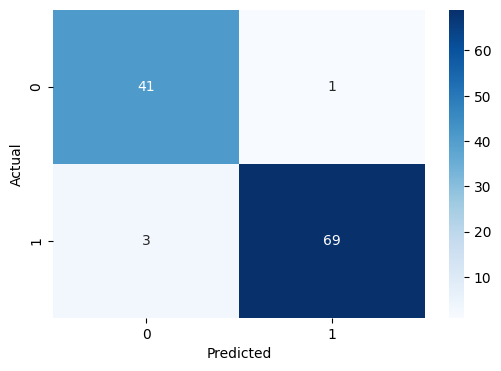

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [47]:
import joblib

model.save('model_weights.h5') 
joblib.dump(scaler, 'scaler_weights.pkl')

['scaler_weights.pkl']